In [ ]:
import os

possible_paths = [
    "/content/drive/MyDrive/CaneGuard_AI/data/pest_images/Sugarcane_leafs",
    "/content/drive/MyDrive/CaneGuard_AI/data/pest_images/real",
    "/content/drive/MyDrive/CaneGuard_AI/data/pest_images",
    "/content/drive/MyDrive/CaneGuard_AI/data",
    "/content/drive/MyDrive/CaneGuard_AI"
]

for path in possible_paths:
    print("\nPATH:", path)
    print("Exists:", os.path.exists(path))
    if os.path.exists(path):
        print("Contents:", os.listdir(path)[:20])

In [ ]:
import os

base_path = "/content/drive/MyDrive/CaneGuard_AI/data/pest_images/real"

if not os.path.exists(base_path):
    raise FileNotFoundError(f"Dataset folder not found: {base_path}")

print("Dataset found at:", base_path)
print("\nClasses found:")

for cls in sorted(os.listdir(base_path)):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        print(cls, ":", len(os.listdir(cls_path)))

DATA_ROOT = base_path

In [ ]:
# ============================================================
# CaneGuard AI - Sugarcane Disease Detection
# EfficientNetB0 / ResNet50 + Grad-CAM + Treatment Card
# ============================================================

!pip -q install split-folders

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import splitfolders

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# 1. Dataset Path
# ============================================================

base_path = "/content/drive/MyDrive/CaneGuard_AI/data/pest_images/real"

if not os.path.exists(base_path):
    raise FileNotFoundError(base_path)

print("Dataset found at:", base_path)
print("\nClasses found:")
for cls in sorted(os.listdir(base_path)):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        print(cls, ":", len(os.listdir(cls_path)))

# ============================================================
# 2. Train / Validation / Test Split
# ============================================================

SPLIT_DIR = "/content/caneguard_split"

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

splitfolders.ratio(
    base_path,
    output=SPLIT_DIR,
    seed=SEED,
    ratio=(0.70, 0.15, 0.15)
)

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

print("\nSplit completed.")
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

# ============================================================
# 3. Load Dataset
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("\nClass names:", class_names)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# ============================================================
# 4. Choose Model Backbone
# ============================================================
# Use "EfficientNetB0" first.
# If accuracy is weak, try "ResNet50".

BACKBONE = "EfficientNetB0"   # options: "EfficientNetB0", "ResNet50"

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.12),
    layers.RandomTranslation(0.06, 0.06),
], name="data_augmentation")

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

if BACKBONE == "EfficientNetB0":
    # Important: do NOT rescale manually for Keras EfficientNet.
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    x = base_model(x, training=False)

elif BACKBONE == "ResNet50":
    # ResNet needs preprocess_input.
    preprocess = tf.keras.applications.resnet50.preprocess_input
    base_model = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    x = layers.Lambda(preprocess, name="resnet_preprocess")(x)
    x = base_model(x, training=False)

else:
    raise ValueError("Invalid BACKBONE selected.")

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs, name=f"CaneGuard_{BACKBONE}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# 5. Callbacks
# ============================================================

MODEL_DIR = "/content/drive/MyDrive/CaneGuard_AI/models"
OUTPUT_DIR = "/content/drive/MyDrive/CaneGuard_AI/outputs"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(MODEL_DIR, f"caneguard_{BACKBONE}_best.keras")

callbacks = [
    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# ============================================================
# 6. Phase 1 Training
# ============================================================

history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)





TensorFlow: 2.20.0
GPU: []
Dataset found at: /content/drive/MyDrive/CaneGuard_AI/data/pest_images/real

Classes found:
Healthy : 522
Mosaic : 462
RedRot : 518
Rust : 514
Yellow : 505


Copying files: 2521 files [00:16, 151.62 files/s]


Split completed.
Train: /content/caneguard_split/train
Validation: /content/caneguard_split/val
Test: /content/caneguard_split/test
Found 1762 files belonging to 5 classes.


Found 376 files belonging to 5 classes.
Found 383 files belonging to 5 classes.

Class names: ['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']


Model: "CaneGuard_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,936 (16.73 MB)

 Trainable params: 332,293 (1.27 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5485 - loss: 1.4144
Epoch 1: val_accuracy improved from None to 0.76596, saving model to /content/drive/MyDrive/CaneGuard_AI/models/caneguard_EfficientNetB0_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CaneGuard_AI/models/caneguard_EfficientNetB0_best.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.6504 - loss: 1.0899 - val_accuracy: 0.7660 - val_loss: 0.6570 - learning_rate: 0.0010
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7599 - loss: 0.6851
Epoch 2: val_accuracy improved from 0.76596 to 0.81649, saving model to /content/drive/MyDrive/CaneGuard_AI/models/caneguard_EfficientNetB0_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CaneGuard_AI/models/caneguard_EfficientNetB0_best.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.7628 - loss: 0.6900 - val_accuracy: 0.8165 - val_loss: 0.5102 - learning_rate: 0.0010
Epoch 3/15
111/111 

In [ ]:
# ============================================================
# 7. Phase 2 Fine-Tuning
# ============================================================

base_model.trainable = True

fine_tune_at = len(base_model.layers) - 35

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

model = tf.keras.models.load_model(BEST_MODEL_PATH)


Epoch 1/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7190 - loss: 0.8107
Epoch 1: val_accuracy did not improve from 0.85372
111/111 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.7333 - loss: 0.7656 - val_accuracy: 0.8218 - val_loss: 0.4673 - learning_rate: 1.0000e-05
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7366 - loss: 0.7154
Epoch 2: val_accuracy did not improve from 0.85372
111/111 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.7429 - loss: 0.6775 - val_accuracy: 0.8324 - val_loss: 0.4710 - learning_rate: 1.0000e-05
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7474 - loss: 0.6875
Epoch 3: val_accuracy did not improve from 0.85372

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
111/111 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.7526 - loss: 0.6775 - val_accuracy: 0.8271 - val_loss: 0.4649 - learning_rate: 1.0000e-05
Epoch 4/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7598 - loss

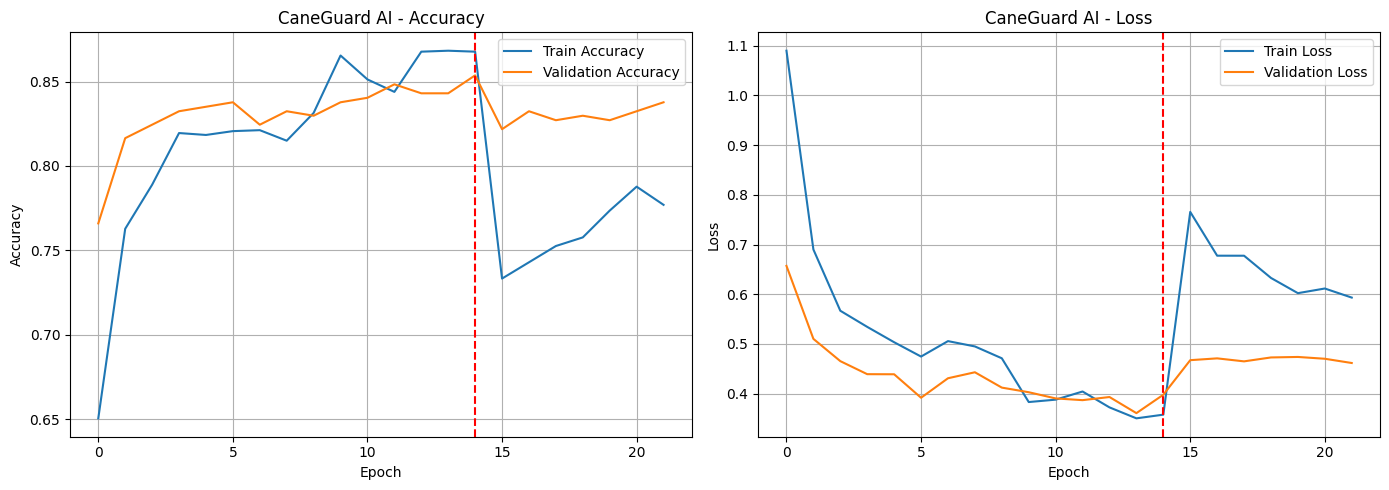

In [ ]:
# ============================================================
# 8. Training Curves
# ============================================================

acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]
loss = history_1.history["loss"] + history_2.history["loss"]
val_loss = history_1.history["val_loss"] + history_2.history["val_loss"]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.axvline(len(history_1.history["accuracy"]) - 1, color="red", linestyle="--")
plt.title("CaneGuard AI - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.axvline(len(history_1.history["loss"]) - 1, color="red", linestyle="--")
plt.title("CaneGuard AI - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{BACKBONE}_training_curves.png"), dpi=150)
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8564 - loss: 0.3822

Final Test Accuracy: 85.64%
Final Test Loss: 0.3822

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.85      0.89      0.87        79
      Mosaic       0.89      0.81      0.85        70
      RedRot       0.89      0.82      0.86        79
        Rust       0.80      0.94      0.86        78
      Yellow       0.86      0.82      0.84        77

    accuracy                           0.86       383
   macro avg       0.86      0.86      0.86       383
weighted avg       0.86      0.86      0.86       383



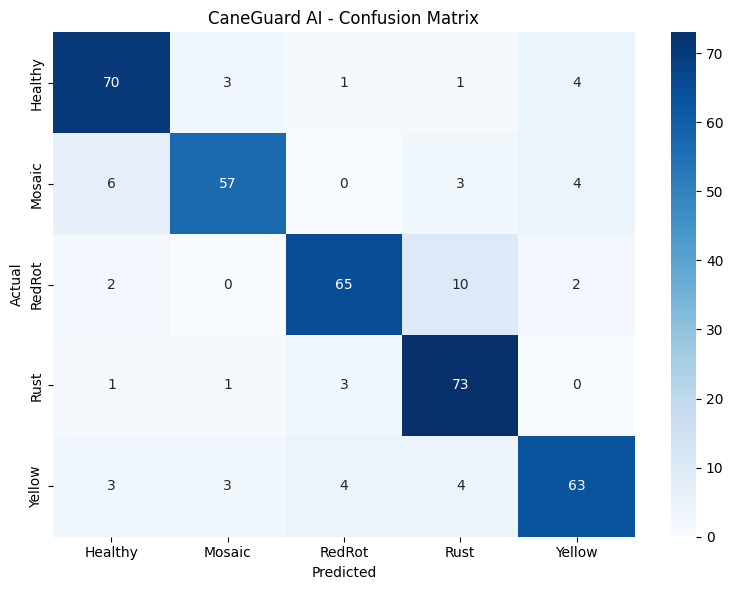

In [ ]:
# ============================================================
# 9. Test Evaluation
# ============================================================

test_loss, test_acc = model.evaluate(test_ds)

print("\n" + "=" * 60)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")
print("=" * 60)

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("CaneGuard AI - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{BACKBONE}_confusion_matrix.png"), dpi=150)
plt.show()


In [ ]:
# ============================================================
# 10. Treatment Cards
# ============================================================

treatments = {
    "Healthy": {
        "status": "Crop is Healthy",
        "action": "Continue regular monitoring every 7 days. Avoid unnecessary pesticide use.",
        "urgency": "No immediate action",
        "impact": "Saves pesticide cost"
    },
    "Mosaic": {
        "status": "Mosaic Disease Detected",
        "action": "Remove severely infected plants. Control aphid vectors and use disease-free planting material.",
        "urgency": "Act within 2 days",
        "impact": "Early action reduces field spread"
    },
    "RedRot": {
        "status": "Red Rot Detected",
        "action": "Remove and destroy infected clumps. Avoid infected cane as seed. Improve drainage.",
        "urgency": "Immediate action required",
        "impact": "Can prevent major yield loss"
    },
    "Rust": {
        "status": "Rust Disease Detected",
        "action": "Monitor spread. Use recommended fungicide after local KVK/agriculture expert confirmation.",
        "urgency": "Act within 3-5 days",
        "impact": "Protects leaf area and crop growth"
    },
    "Yellow": {
        "status": "Yellow Leaf Symptoms Detected",
        "action": "Check nutrient deficiency, water stress, and disease symptoms. Use balanced nutrition after diagnosis.",
        "urgency": "Monitor daily",
        "impact": "Early correction improves recovery"
    }
}


In [ ]:
# ============================================================
# Fixed Grad-CAM for Nested EfficientNetB0 Model
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def get_backbone_layer(model):
    for layer in model.layers:
        if "efficientnet" in layer.name.lower() or "resnet" in layer.name.lower():
            return layer
    raise ValueError("Backbone model not found.")

backbone_model = get_backbone_layer(model)
print("Backbone:", backbone_model.name)

def find_last_conv_layer(backbone_model):
    for layer in reversed(backbone_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in backbone.")

LAST_CONV_LAYER = find_last_conv_layer(backbone_model)
print("Last Conv Layer:", LAST_CONV_LAYER)

def make_gradcam_heatmap_fixed(img_array, model, backbone_model, last_conv_layer_name, pred_index=None):
    feature_extractor = tf.keras.models.Model(
        inputs=backbone_model.input,
        outputs=[
            backbone_model.get_layer(last_conv_layer_name).output,
            backbone_model.output
        ]
    )

    backbone_index = None
    for i, layer in enumerate(model.layers):
        if layer.name == backbone_model.name:
            backbone_index = i
            break

    head_layers = model.layers[backbone_index + 1:]

    with tf.GradientTape() as tape:
        conv_outputs, backbone_output = feature_extractor(img_array, training=False)

        x = backbone_output
        for layer in head_layers:
            if isinstance(layer, tf.keras.layers.Dropout):
                x = layer(x, training=False)
            else:
                x = layer(x)

        predictions = x

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

def show_gradcam_fixed(img_path, alpha=0.45):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(preds[0])
    predicted_class = class_names[pred_idx]
    confidence = preds[0][pred_idx] * 100

    heatmap = make_gradcam_heatmap_fixed(
        img_batch,
        model,
        backbone_model,
        LAST_CONV_LAYER,
        pred_index=pred_idx
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = tf.keras.utils.array_to_img(np.expand_dims(heatmap, axis=-1))
    heatmap = heatmap.resize((224, 224))
    heatmap = tf.keras.utils.img_to_array(heatmap)

    cmap = plt.cm.jet(heatmap[:, :, 0] / 255.0)[:, :, :3]
    cmap = np.uint8(cmap * 255)

    superimposed = cmap * alpha + img_array
    superimposed = superimposed / np.max(superimposed)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_array.astype("uint8"))
    plt.title("Original Leaf Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed)
    plt.title(f"Grad-CAM: {predicted_class} ({confidence:.1f}%)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence

Backbone: efficientnetb0
Last Conv Layer: top_conv


In [ ]:
def caneguard_predict_fixed(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    probs = model.predict(img_batch, verbose=0)[0]
    pred_idx = np.argmax(probs)
    predicted_class = class_names[pred_idx]
    confidence = probs[pred_idx] * 100

    info = treatments[predicted_class]

    print("\n" + "=" * 65)
    print("CaneGuard AI - Sugarcane Disease Detection Report")
    print("=" * 65)
    print(f"Predicted Disease: {predicted_class}")
    print(f"Confidence Score: {confidence:.2f}%")
    print(f"Crop Status: {info['status']}")
    print(f"Recommended Action: {info['action']}")
    print(f"Urgency: {info['urgency']}")
    print(f"Economic Impact: {info['impact']}")
    print("=" * 65)

    show_gradcam_fixed(img_path)

    return predicted_class, confidence

Testing image: /content/caneguard_split/test/RedRot/redrot (352).jpeg

CaneGuard AI - Sugarcane Disease Detection Report
Predicted Disease: Yellow
Confidence Score: 91.67%
Crop Status: Yellow Leaf Symptoms Detected
Recommended Action: Check nutrient deficiency, water stress, and disease symptoms. Use balanced nutrition after diagnosis.
Urgency: Monitor daily
Economic Impact: Early correction improves recovery


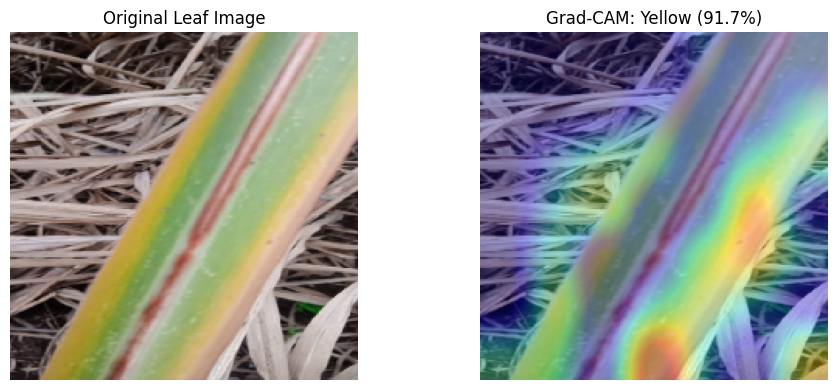

('Yellow', np.float32(91.67102))

In [ ]:
# ============================================================
# 13. Test on Random Image
# ============================================================

sample_class = random.choice(class_names)
sample_folder = os.path.join(TEST_DIR, sample_class)
sample_image = os.path.join(sample_folder, random.choice(os.listdir(sample_folder)))

print("Testing image:", sample_image)
caneguard_predict_fixed(sample_image)

Upload a sugarcane leaf image in JPG, JPEG, or PNG format


Saving WhatsApp Image 2026-05-31 at 8.54.03 PM.jpeg to WhatsApp Image 2026-05-31 at 8.54.03 PM.jpeg

Uploaded Image: WhatsApp Image 2026-05-31 at 8.54.03 PM.jpeg

CaneGuard AI - Sugarcane Disease Detection Report
Predicted Disease: Rust
Confidence Score: 93.32%
Crop Status: Rust Disease Detected
Recommended Action: Monitor spread. Use recommended fungicide after local KVK/agriculture expert confirmation.
Urgency: Act within 3-5 days
Economic Impact: Protects leaf area and crop growth


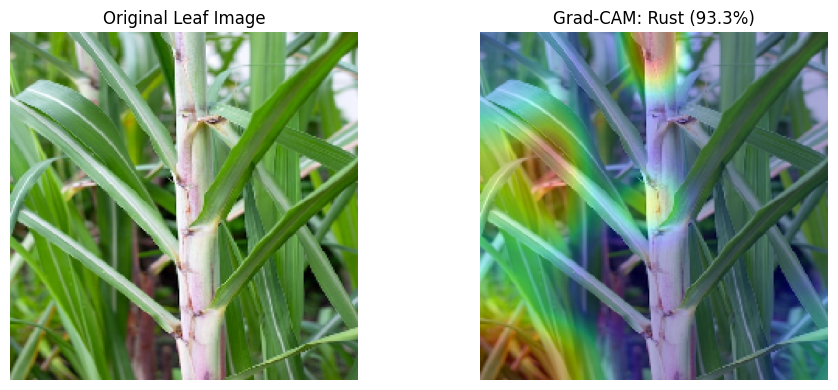

In [ ]:
# ============================================================
# Upload Your Own Sugarcane Leaf Image and Predict
# ============================================================

from google.colab import files
import os

print("Upload a sugarcane leaf image in JPG, JPEG, or PNG format")

uploaded = files.upload()

for uploaded_file in uploaded.keys():
    file_ext = uploaded_file.lower().split(".")[-1]

    if file_ext not in ["jpg", "jpeg", "png"]:
        print(f"Skipping {uploaded_file}: unsupported file format")
        continue

    print("\nUploaded Image:", uploaded_file)
    caneguard_predict_fixed(uploaded_file)